# Heart Failure (HF) Prediction using Machine Learning

Author: Jesús Jiménez Serrano  

# 1. Problem Description

HF management remains hindered by the limitations of traditional linear models in capturing the complex, non-linear clinical patterns inherent in patient data. With this study, we try to see which variables have the greatest influence on this prediction

# 2. Exploring Dataset

Step 1. Import the neccesary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

Step 2. Load the dataset

In [3]:
df = pd.read_csv('heart.csv')

Step 3. First visual analysis

In [4]:
print(df.head(5))

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB
None


In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Now, I want to know how many patients have the disease, and how many do not, in order to verify the balance of the dataset

In [7]:
print(df['HeartDisease'].value_counts())

HeartDisease
1    508
0    410
Name: count, dtype: int64


# 3. Data Quality and Cleaning

Step 1. Check for duplicates

In [8]:
df = df.drop_duplicates()
print(len(df))

918


Step 2. See if there are missing values, and in that case, deal with them

In [9]:
cols_with_null_values = df.columns[df.isnull().any()].tolist()
print(cols_with_null_values)


[]


In this case, there are no missing values, but, as we can see with df.describe(), for columns = 'RestingBP' and 'Cholesterol' the minimum value is 0, which is clinically impossible, so I have to deal with that

In [10]:
print(f"There are {(df['Cholesterol'] == 0).sum()} zero values for Cholesterol")
print(f"There are {(df['RestingBP'] == 0).sum()} zero values for RestingBP")


There are 172 zero values for Cholesterol
There are 1 zero values for RestingBP


With that results, I will drop the unique row for RestingBP == 0, and for the Cholesterol == 0 rows, as there are a lot (almost 20% of the total dataset), I will replace that value with the positive values median 

In [11]:
df = df[df['RestingBP'] != 0]
cholesterol_median = df[df['Cholesterol'] > 0]['Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, cholesterol_median)

Step 3. Check if there are outliers. First, I will check automatically which columns have outliers and its respective percentage. Then, I will assess them individually, understanding the context

In [12]:
numeric_columns = df.select_dtypes(include=['float64','int64']).columns.tolist()
print(numeric_columns)
#Within this context, the columns 'Age', 'MaxHR' and 'HeartDisease' don´t make sense to review their outliers
columns_to_remove = ['Age', 'MaxHR', 'HeartDisease']
numeric_columns = [c for c in numeric_columns if c not in columns_to_remove]
report = [] #List with dictionaries inside it
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR 
    upper_limit = Q3 + 1.5 * IQR
    number_outliers = ((df[col] < lower_limit) | (df[col] > upper_limit)).sum()
    if df[col].count() > 0:
        percentage = number_outliers * 100 / df[col].count()
    else:
        raise ZeroDivisionError("No se puede dividir entre cero")
    report.append({
        "Variable": col,
        "IQR (25-75%)": f"{Q1:.2f} - {Q3:.2f}",
        "Lower limit": lower_limit,
        "Upper Limit": upper_limit,
        "Percentage of Outliers": percentage
    })

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']


Now, with the information included in the list, I have to work with it. First, I will show it in a more visual way

In [13]:
df_outliers = pd.DataFrame(report) #Make a DataFrame from a dictionary list
df_outliers = df_outliers.sort_values(by='Percentage of Outliers', ascending=False)
print(df_outliers)

      Variable     IQR (25-75%)  Lower limit  Upper Limit  \
2    FastingBS      0.00 - 0.00         0.00         0.00   
1  Cholesterol  214.00 - 267.00       134.50       346.50   
0    RestingBP  120.00 - 140.00        90.00       170.00   
3      Oldpeak      0.00 - 1.50        -2.25         3.75   

   Percentage of Outliers  
2               23.336968  
1                4.471101  
0                2.944384  
3                1.744820  


As FastingBS is a variable which may take values = 0 or 1, it is normal to have that high percentage. For the rest of them, results are quite normal, I won´t take action on them

# 4. Graphic Visualization - Exploring Data Analysis (EDA)

*  This will help us trying to see some correlations or patterns in the dataset before anything else.

Step 1. Which chest pain leads to a higher number of HF disease?

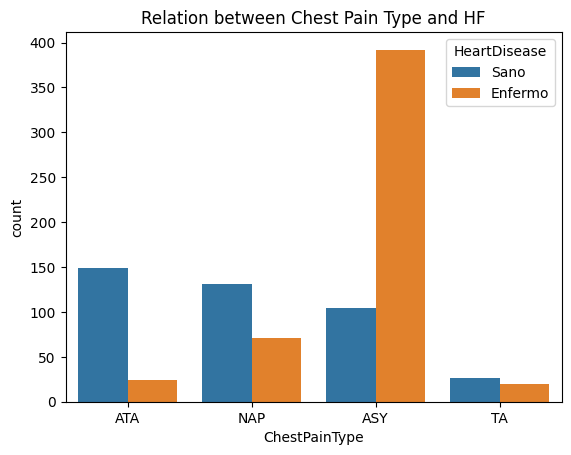

In [14]:
sns.countplot(x='ChestPainType', hue=df['HeartDisease'].map({0: 'Sano', 1: 'Enfermo'}), data=df)
plt.title('Relation between Chest Pain Type and HF')
plt.show()

As we can see, the highest correlation comes with ASY (asymptomatic) and having HF. On the other hand, when having ATA (atypical angina) is more likely to not have HF

Step 2. Does sex interfere with the disease? And age?

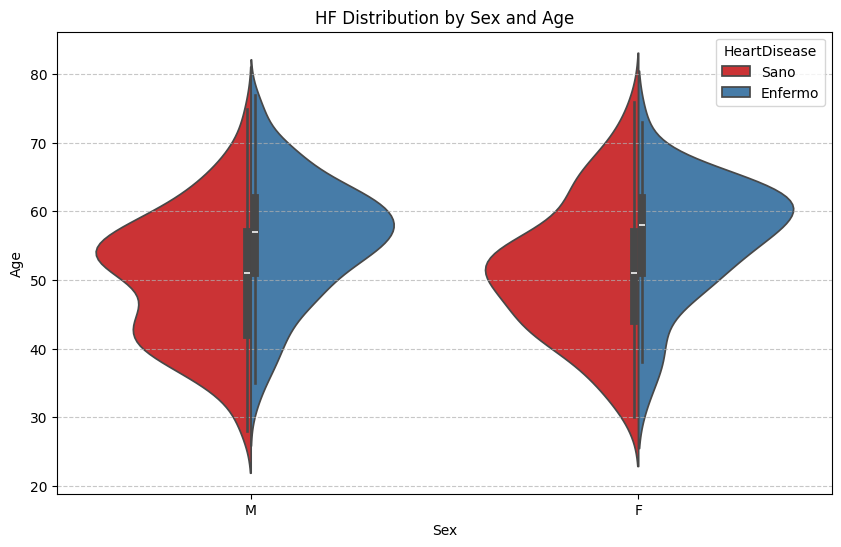

In [15]:
plt.figure(figsize=(10,6))
sns.violinplot(x='Sex', y='Age', hue=df['HeartDisease'].map({0: 'Sano', 1: 'Enfermo'}), data=df, split=True, palette='Set1')
plt.title('HF Distribution by Sex and Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

With this plot we can affirm that HF develops later in women than in men (early 60's versus late 50's)

Step 3. Does the slope of the peak exercise ST segment (ST_Slope) have real impact on the diagnosis?

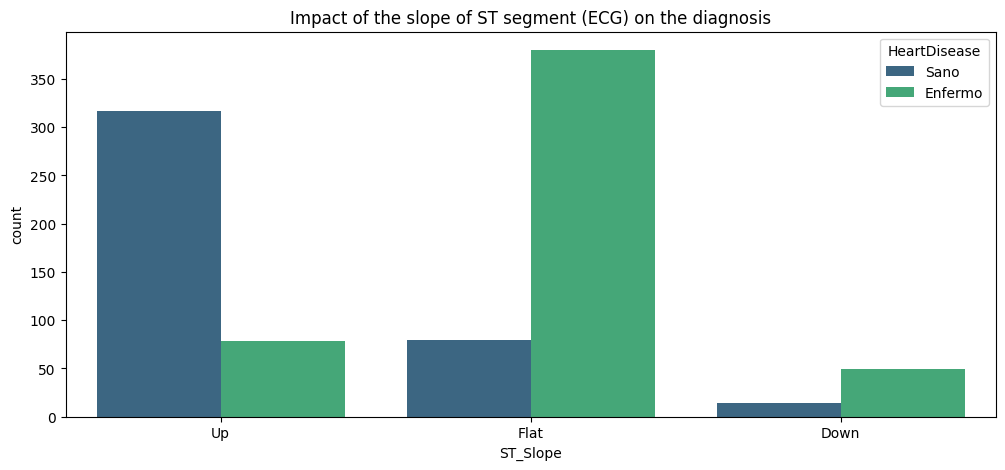

In [16]:
plt.figure(figsize=(12, 5))
sns.countplot(x='ST_Slope', hue=df['HeartDisease'].map({0: 'Sano', 1: 'Enfermo'}), data=df, palette='viridis')
plt.title('Impact of the slope of ST segment (ECG) on the diagnosis')
plt.show()

We can highly guarantee that, with a flat ST_Slope, worse results are expected. Quite the opposite with the upsloping (Up) ST segment

# 5. Data Preprocessing & Feature Engineering

In this specific case, we have text rows which may be useful for the outcome (for example: , etc). Understanding the context, we know this columns will have impact in the output price, but we cannot give to our model text columns, so I need to create new columns to label them. 

In [17]:
text_columns = df.select_dtypes(include=['str']).columns.tolist()
print(text_columns)

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


* Label Encoding is used for variables which either have only two options, or when the categories have a natural order.
* One-Hot Encoding is used for variables which categories have no inherent order.
* With this clear, I will be using Label Encoding for 'Sex' and 'ExerciseAngina', and One-Hot Encoding for 'ChestPainType', 'RestingECG' and 'ST_Slope'

In [18]:
#Label Encoding columns
cols_to_label_encode = ['Sex', 'ExerciseAngina']
label_encoders = {} #Dictionary to save the "traduction": Key: Column, Value: LabelEncoder() Object
for col in cols_to_label_encode:
    le = LabelEncoder()
    df[f"{col}_Label"] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

#One-Hot Encoding columns
df_encoded = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True)
print(f"There are {len(df_encoded.columns)-len(df.columns)} columns of difference from original Dataframe")
print(df_encoded)

#Reference: https://www.geeksforgeeks.org/machine-learning/one-hot-encoding-vs-label-encoding/

There are 4 columns of difference from original Dataframe
     Age Sex  RestingBP  Cholesterol  FastingBS  MaxHR ExerciseAngina  \
0     40   M        140          289          0    172              N   
1     49   F        160          180          0    156              N   
2     37   M        130          283          0     98              N   
3     48   F        138          214          0    108              Y   
4     54   M        150          195          0    122              N   
..   ...  ..        ...          ...        ...    ...            ...   
913   45   M        110          264          0    132              N   
914   68   M        144          193          1    141              N   
915   57   M        130          131          0    115              Y   
916   57   F        130          236          0    174              N   
917   38   M        138          175          0    173              N   

     Oldpeak  HeartDisease  Sex_Label  ExerciseAngina_Label  \
0 

I will expose the LabelEncoder "traduction" before I drop that string columns

In [19]:
encoder = label_encoders['Sex']
dictionary_sex = pd.DataFrame({"Original_Text": encoder.classes_,
                                   "Numeric Code": range(len(encoder.classes_))})
display(dictionary_sex)
encoder = label_encoders['ExerciseAngina']
dictionary_exang = pd.DataFrame({"Original_Text": encoder.classes_,
                                   "Numeric Code": range(len(encoder.classes_))})
display(dictionary_exang)

,Original_Text,Numeric Code
0,F,0
1,M,1


,Original_Text,Numeric Code
0,N,0
1,Y,1


With this information displayed, now it´s time to drop the columns off, and see which columns do we have on our DataFrame

In [20]:
df = df_encoded.drop(['Sex', 'ExerciseAngina'], axis=1)
#I´m gonna make sure there are no string columns left
print(df.info())

<class 'pandas.DataFrame'>
Index: 917 entries, 0 to 917
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   917 non-null    int64  
 1   RestingBP             917 non-null    int64  
 2   Cholesterol           917 non-null    int64  
 3   FastingBS             917 non-null    int64  
 4   MaxHR                 917 non-null    int64  
 5   Oldpeak               917 non-null    float64
 6   HeartDisease          917 non-null    int64  
 7   Sex_Label             917 non-null    int64  
 8   ExerciseAngina_Label  917 non-null    int64  
 9   ChestPainType_ATA     917 non-null    bool   
 10  ChestPainType_NAP     917 non-null    bool   
 11  ChestPainType_TA      917 non-null    bool   
 12  RestingECG_Normal     917 non-null    bool   
 13  RestingECG_ST         917 non-null    bool   
 14  ST_Slope_Flat         917 non-null    bool   
 15  ST_Slope_Up           917 non-null    b

# 6. Correlation Maps
We want to see which specific rows have real impact in the disease prediction, using a correlation matrix. In the end, we must take features near to +1 (perfect positive correlation) or -1 (perfect negative correlation), while features near to 0 are simply experimental noise, we won´t want them.

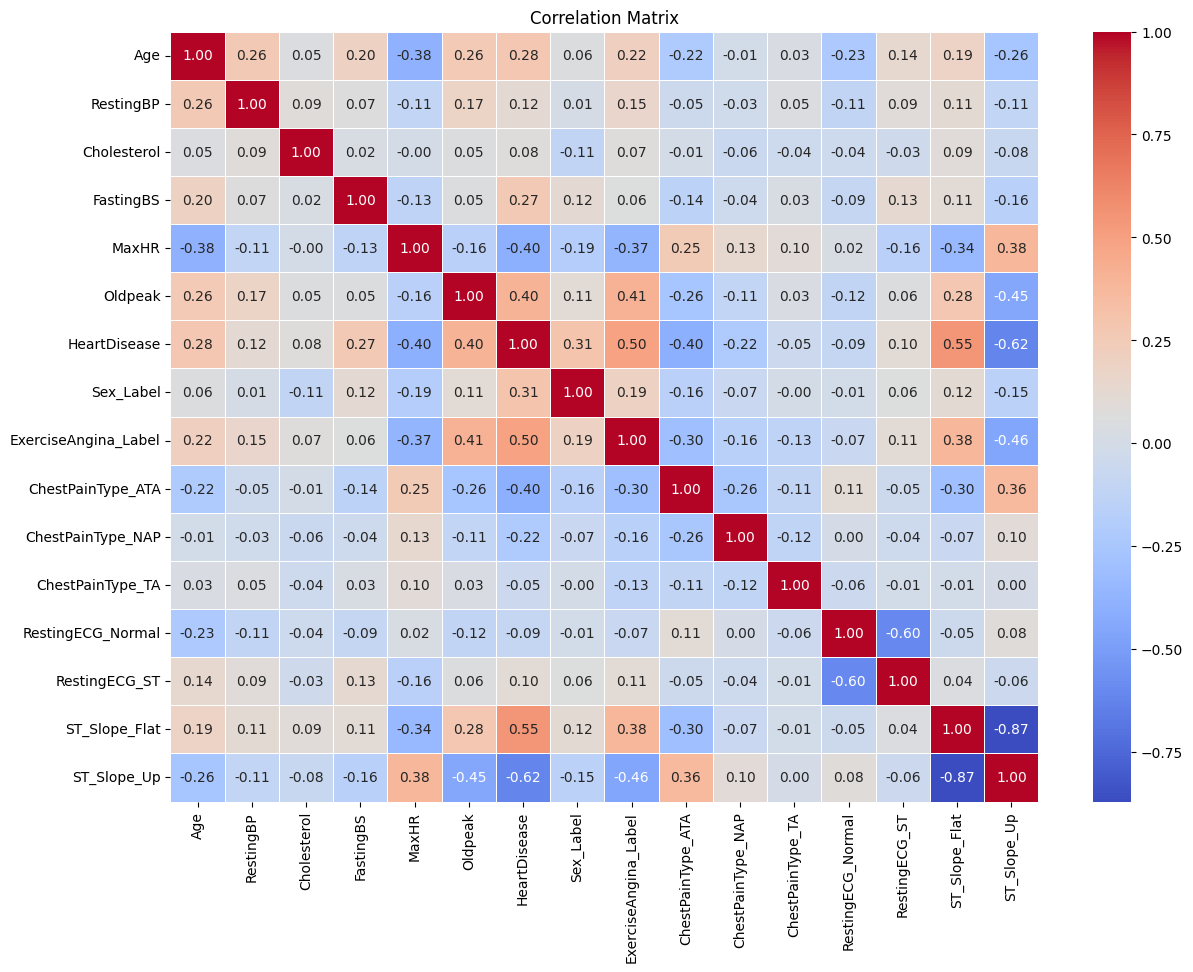

In [21]:
# Calculate the correlation
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()

# Heatmap plot
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

Now, I want to see the correlation only with the output variable (HeartDisease), and see which variables has the most correlation with (this is hugely important)

In [22]:
# See which of them have higher correlation with the disease
print("Correlation with HeartDisease (from higher to lower):")
print(correlation_matrix['HeartDisease'].sort_values(ascending=False))

Correlation with HeartDisease (from higher to lower):
HeartDisease            1.000000
ST_Slope_Flat           0.553700
ExerciseAngina_Label    0.495490
Oldpeak                 0.403638
Sex_Label               0.305118
Age                     0.282012
FastingBS               0.267994
RestingBP               0.117990
RestingECG_ST           0.103067
Cholesterol             0.076262
ChestPainType_TA       -0.054591
RestingECG_Normal      -0.092452
ChestPainType_NAP      -0.215311
MaxHR                  -0.401410
ChestPainType_ATA      -0.401680
ST_Slope_Up            -0.621843
Name: HeartDisease, dtype: float64


# 7. Model Selection & Training
I chose a Decision Tree because its 'white-box' nature provides clear, easy-to-follow rules that medical professionals can trust and verify.

In [23]:
#First, I have to make sure again that there are no missing values
if df.isnull().sum().sum() > 0:
    print(f"There are {df.isnull().sum()} NaN values. The model will fail")
else:
    print("There are no missing values, the model will -supposedly- run")
#Now, I have to divide my dataset into X values and Y value (which will be X for all columns except the target one, and Y the target column)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']
#Next thing is divide data into training (80%) and testing (20%)
#random_state=42 ensures that results are reproducible (ensure same random seed for each trial)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"We will have {X_train.shape[0]} samples for training")
print(f"We will have {X_test.shape[0]} samples for testing")

There are no missing values, the model will -supposedly- run
We will have 733 samples for training
We will have 184 samples for testing


Now, I will implement the ML Model itself. 

In [24]:
#I´m limiting the depth to 3 or 4 to be interpretable (what doctors would like)
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

# 8. Model Evaluation

Finally, this stage has · main objectives: draw the tree decision to see which variables has it take into account, obtain its accuracy and the confussion matrix (very important in medical field)

In [25]:
y_pred = tree_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Our model has a final accuracy of {accuracy * 100:.2f}%")

Our model has a final accuracy of 83.15%


Now, I will plot the confusion matrix, specially to see False Negatives (FN). This is, ill patient who has been treated as healthy (which is the most critical error)

<Figure size 800x600 with 0 Axes>

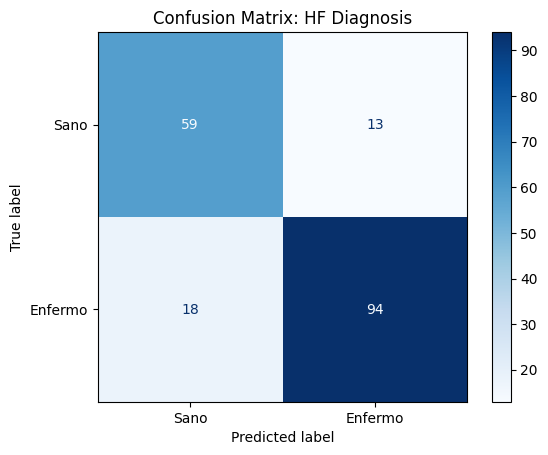

In [26]:
cm = confusion_matrix(y_test, y_pred)

#Plot it
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano', 'Enfermo'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: HF Diagnosis')
plt.show()

Finally, the tree will be displayed

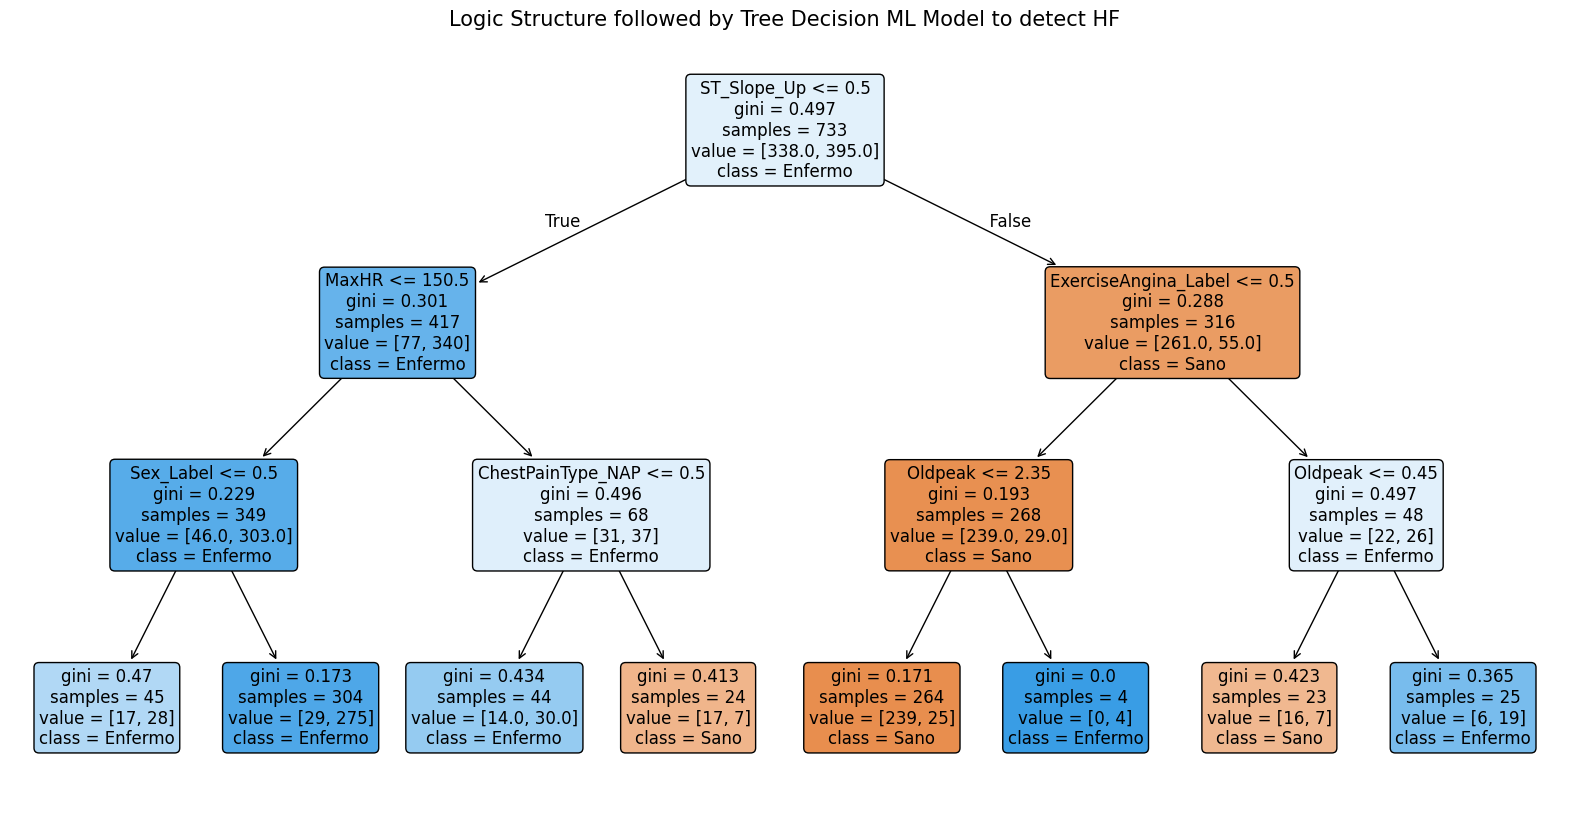

In [27]:
plt.figure(figsize=(20,10))
plot_tree(tree_model, 
          feature_names=X.columns,           
          class_names=['Sano', 'Enfermo'],   
          filled=True,                       
          rounded=True,                      
          fontsize=12)

plt.title("Logic Structure followed by Tree Decision ML Model to detect HF", fontsize=15)
plt.show()